# NB 31 — Model evaluation (FE 46ch detrended PCA)

Mirror of NB 14 but for the **FE pipeline**:
* Model: `models/pca_fe_46ch.pkl` — 46-channel detrended PCA (Tier A+B dropped, k≈316, EV≈0.95)
* Splits: kaggle 80/20, with the 20% labelled tail carved into
  `val = rows 10.7M..12.7M` and `test = rows 12.7M..14.7M`
  (`train_full_scaled` is already RobustScaler-scaled).
* Recipe: per-channel rolling-median input detrend (window 100k) +
  `score_windows_detrended` (window 1000 windows = 100k rows, mode 'median').
* Headline: `corrected_event_f05` (= ESA F0.5 = Pr_ew × TNR), tuned on val.
* Optional FE post-filter: `clean_predictions(min_len=100, max_gap=500)`.

---
## 1 - Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys, json, pickle, time
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy.ndimage import median_filter

from sentinel.ml_logic.data       import PROCESSED_DIR, MODELS_DIR, RAW_DIR
from sentinel.ml_logic.data       import find_anomaly_segments
from sentinel.ml_logic.scorer     import (score_windows_detrended, score_report,
                                          clean_predictions)
from sentinel.ml_logic.thresholds import tune_threshold
from sentinel.ml_logic.metrics    import (
    event_f05, event_f1, event_f2, corrected_event_f05,
    row_precision_recall, compute_all_metrics,
)
from sentinel.ml_logic.validation import bootstrap_f05_ci
from sentinel.ml_logic.viz        import plot_confusion_and_channel_errors, plot_timeline
from sentinel.params              import ANOMALY_COLOR, NOMINAL_COLOR, WINDOW_SIZE

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

TRAIN_END = 10_700_000
VAL_END   = 12_700_000
WIN       = WINDOW_SIZE
KAGGLE    = PROCESSED_DIR / 'kaggle'
print(f'Ready. WIN={WIN}, val=({TRAIN_END:,}..{VAL_END:,}), test=({VAL_END:,}..end)')

Ready. WIN=100, val=(10,700,000..12,700,000), test=(12,700,000..end)


### Load the FE 46ch model + sidecar

The sidecar carries the val-tuned threshold and the post-filter config so
this notebook stays in sync with whatever `scripts/train_fe46.py` last produced.

In [2]:
PROJECT_ROOT = Path('..').resolve()
MODEL_PATH   = MODELS_DIR / 'pca_fe_46ch.pkl'
SIDECAR_PATH = sorted(MODELS_DIR.glob('fe_46ch_*.json'))[-1]

with open(MODEL_PATH, 'rb') as f:
    model = pickle.load(f)
with open(SIDECAR_PATH) as f:
    sidecar = json.load(f)

FEATURES_FE = list(
    pd.read_csv(PROJECT_ROOT / sidecar['features_csv'])['target_channels']
)
MODEL_NAME      = MODEL_PATH.stem
BAKED_THRESHOLD = float(sidecar['threshold'])
POST_CFG        = sidecar['post_filter']
INPUT_DETREND_WIN = sidecar['input_detrend']['window']
SCORE_DETREND_WIN = sidecar['score_detrend']['window_in_windows']

print(f'model           : {MODEL_NAME}  k={model.n_components_}  '
      f'EV={model.explained_variance_ratio_.sum():.4f}')
print(f'sidecar         : {SIDECAR_PATH.name}  (trained {sidecar["trained_at"]})')
print(f'channels        : {len(FEATURES_FE)}  (Tier A+B dropped)')
print(f'baked threshold : {BAKED_THRESHOLD:.6f}    val ESA F0.5 = {sidecar["val_esa_f05"]:.4f}')
print(f'input  detrend  : window {INPUT_DETREND_WIN:,} rows, mode median')
print(f'score  detrend  : window {SCORE_DETREND_WIN:,} windows = '
      f'{SCORE_DETREND_WIN*WIN:,} rows, mode median')
print(f'post-filter     : min_len={POST_CFG["min_len"]}, max_gap={POST_CFG["max_gap"]}')

model           : pca_fe_46ch  k=316  EV=0.9501
sidecar         : fe_46ch_20260429_153751.json  (trained 20260429_153751)
channels        : 46  (Tier A+B dropped)
baked threshold : 0.001970    val ESA F0.5 = 0.8534
input  detrend  : window 100,000 rows, mode median
score  detrend  : window 1,000 windows = 100,000 rows, mode median
post-filter     : min_len=100, max_gap=500


### Load val + test slices and apply the FE input detrend

`train_full_scaled` is already scaled. We slice the 46 FE channels and apply
the per-channel rolling-median input detrend on the **full timeline**, then
carve val (10.7M..12.7M) and test (12.7M..end) out of the detrended array.

Detrending the full timeline (rather than the val/test slices in isolation)
matches `scripts/train_fe46.py` exactly — no boundary leak between val and test.

In [3]:
with open(KAGGLE / 'preprocessing_config.json') as f:
    kcfg = json.load(f)
FEATURES_FULL = kcfg['target_channels']            # 58 names
fe_idx        = np.array([FEATURES_FULL.index(c) for c in FEATURES_FE])

train_full_scaled = np.load(KAGGLE / 'train_full_scaled.npy', mmap_mode='r')
y_train_row       = np.load(KAGGLE / 'y_train_row.npy')

t0 = time.time()
X_full = np.ascontiguousarray(train_full_scaled[:, fe_idx]).astype(np.float32)
print(f'  slice  in {time.time()-t0:.1f}s   shape {X_full.shape}')

t0 = time.time()
X_full_dt = np.empty_like(X_full, dtype=np.float32)
for j in range(X_full.shape[1]):
    col = X_full[:, j]
    X_full_dt[:, j] = col - median_filter(col, size=INPUT_DETREND_WIN, mode='reflect')
print(f'  detrend in {time.time()-t0:.1f}s   window={INPUT_DETREND_WIN:,}')
del X_full

X_val  = np.ascontiguousarray(X_full_dt[TRAIN_END:VAL_END]).astype(np.float32)
X_test = np.ascontiguousarray(X_full_dt[VAL_END:]).astype(np.float32)
y_val  = y_train_row[TRAIN_END:VAL_END]
y_test = y_train_row[VAL_END:]
del X_full_dt

print(f'\n  val   : {X_val.shape}   anom rows: {int(y_val.sum()):,}  ({y_val.mean():.2%})')
print(f'  test  : {X_test.shape}   anom rows: {int(y_test.sum()):,}  ({y_test.mean():.2%})')

  slice  in 5.3s   shape (14728321, 46)
  detrend in 64.7s   window=100,000

  val   : (2000000, 46)   anom rows: 215,798  (10.79%)
  test  : (2028321, 46)   anom rows: 214,935  (10.60%)


---
## 2 - Score val + test (`score_windows_detrended`)

Same call the FE training script and `predict_fe46` make. We also keep the
full `score_report` on each split so the per-channel diagnostic plots later
can use `window_channel_mse`.

In [4]:
t0 = time.time()
scores_val  = score_windows_detrended(model, X_val,  win=WIN,
                                      detrend_window=SCORE_DETREND_WIN,
                                      detrend_mode='median')
scores_test = score_windows_detrended(model, X_test, win=WIN,
                                      detrend_window=SCORE_DETREND_WIN,
                                      detrend_mode='median')
print(f'score_windows_detrended (both splits): {time.time()-t0:.1f}s')
print(f'  val  range  [{scores_val.min():.4f}, {scores_val.max():.4f}]   '
      f'nominal mean {scores_val[y_val==0].mean():.5f}   '
      f'anomaly mean {scores_val[y_val==1].mean():.5f}')
print(f'  test range  [{scores_test.min():.4f}, {scores_test.max():.4f}]   '
      f'nominal mean {scores_test[y_test==0].mean():.5f}   '
      f'anomaly mean {scores_test[y_test==1].mean():.5f}')

# Per-channel diagnostics (no detrend on the score path — we want raw window MSE
# per channel, not the detrended scalar score).
t0 = time.time()
rep_val  = score_report(model, X_val,  win=WIN)
rep_test = score_report(model, X_test, win=WIN)
print(f'score_report (both splits)            : {time.time()-t0:.1f}s')

score_windows_detrended (both splits): 1.7s
  val  range  [-0.0010, 3.6970]   nominal mean 0.00057   anomaly mean 0.00489
  test range  [-0.0060, 1.9403]   nominal mean 0.00041   anomaly mean 0.00546
score_report (both splits)            : 1.7s


---
## 3 - Threshold (val-tuned, `corrected_event_f05`)

Default tunes on val with `corrected_event_f05` — the same metric the FE
training script uses (= ESA F0.5 = Pr_ew × TNR). Set `MANUAL_THRESHOLD` to
override (e.g. `BAKED_THRESHOLD` to reproduce the sidecar).

In [5]:
MANUAL_THRESHOLD = None             # None -> auto-tune,  float -> use as-is
TUNE_METRIC      = corrected_event_f05

sweep = tune_threshold(scores_val, y_val, metric_fn=TUNE_METRIC, n_sweep=80)
if MANUAL_THRESHOLD is None:
    THRESHOLD = sweep['threshold']
    print(f'auto threshold : {THRESHOLD:.6f}  →  val {TUNE_METRIC.__name__} = {sweep["score"]:.4f}')
else:
    THRESHOLD = float(MANUAL_THRESHOLD)
    manual_score = TUNE_METRIC(y_val, (scores_val > THRESHOLD).astype(np.int8))['f_score']
    print(f'manual threshold: {THRESHOLD:.6f}  →  val {TUNE_METRIC.__name__} = {manual_score:.4f}  '
          f'(auto would pick {sweep["threshold"]:.6f} → {sweep["score"]:.4f})')
print(f'baked threshold : {BAKED_THRESHOLD:.6f}    (sidecar value)')

auto threshold : 0.001970  →  val corrected_event_f05 = 0.8534
baked threshold : 0.001970    (sidecar value)


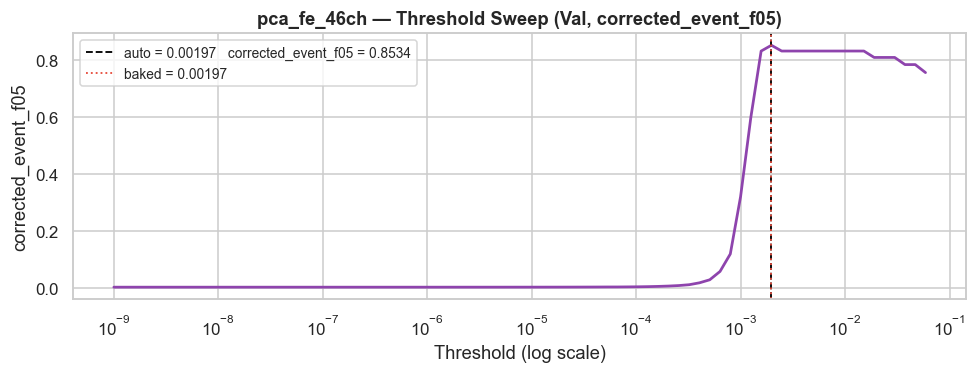

In [6]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(sweep['sweep_thresholds'], sweep['sweep_scores'], color='#8e44ad', lw=1.8)
ax.axvline(THRESHOLD,       color='black',         ls='--', lw=1.2,
           label=f'auto = {THRESHOLD:.5f}   {TUNE_METRIC.__name__} = {sweep["score"]:.4f}')
ax.axvline(BAKED_THRESHOLD, color=ANOMALY_COLOR,    ls=':',  lw=1.2,
           label=f'baked = {BAKED_THRESHOLD:.5f}')
ax.set_xscale('log')
ax.set_xlabel('Threshold (log scale)')
ax.set_ylabel(TUNE_METRIC.__name__)
ax.set_title(f'{MODEL_NAME} — Threshold Sweep (Val, corrected_event_f05)', fontweight='bold')
ax.legend(fontsize=9)
fig.tight_layout(); plt.show()

### Threshold comparison

Evaluate a fan around the auto-tuned threshold on val + test. Use this to pick
by trade-off (precision vs recall vs flag rate). The auto-tuned row is highlighted.

In [7]:
thr_auto = sweep['threshold']
THR_GRID = sorted({
    thr_auto * 0.5, thr_auto * 0.75, thr_auto,
    thr_auto * 1.25, thr_auto * 1.5, thr_auto * 2.0,
    BAKED_THRESHOLD,
})

def _row(scores, y_true, thr):
    y_pred = (scores > thr).astype(np.int8)
    m = compute_all_metrics(y_true, y_pred)
    return {
        'threshold'    : thr,
        'Event F0.5'   : m['event_f05'],
        'Event prec'   : m['event_precision'],
        'Event recall' : m['event_recall'],
        'Events hit'   : f"{m['tp_events']}/{m['n_events']}",
        'FP events'    : int(m['fp_pred_events']),
        'ESA F0.5'     : m['esa_f05'],
        'Row F1'       : m['row_f1'],
        'Pos rate'     : float((y_pred == 1).mean()),
    }

rows_val  = [{'split': 'Val',  **_row(scores_val,  y_val,  t)} for t in THR_GRID]
rows_test = [{'split': 'Test', **_row(scores_test, y_test, t)} for t in THR_GRID]
df_grid = pd.DataFrame(rows_val + rows_test).set_index(['split', 'threshold'])

def _highlight_auto(row):
    is_auto = np.isclose(row.name[1], thr_auto)
    return ['background-color: #fff3bf' if is_auto else '' for _ in row]

print(f'{MODEL_NAME} — threshold comparison  (auto = {thr_auto:.6f}, baked = {BAKED_THRESHOLD:.6f})')
df_grid.style.apply(_highlight_auto, axis=1).format({
    'threshold'    : '{:.6f}',
    'Event F0.5'   : '{:.4f}',
    'Event prec'   : '{:.4f}',
    'Event recall' : '{:.4f}',
    'ESA F0.5'     : '{:.4f}',
    'Row F1'       : '{:.4f}',
    'Pos rate'     : '{:.2%}',
})

pca_fe_46ch — threshold comparison  (auto = 0.001970, baked = 0.001970)


---
## 4 — Score distribution

Histograms of the row-level (detrended) score, split by ground-truth label.
The threshold line shows how cleanly the two populations separate.

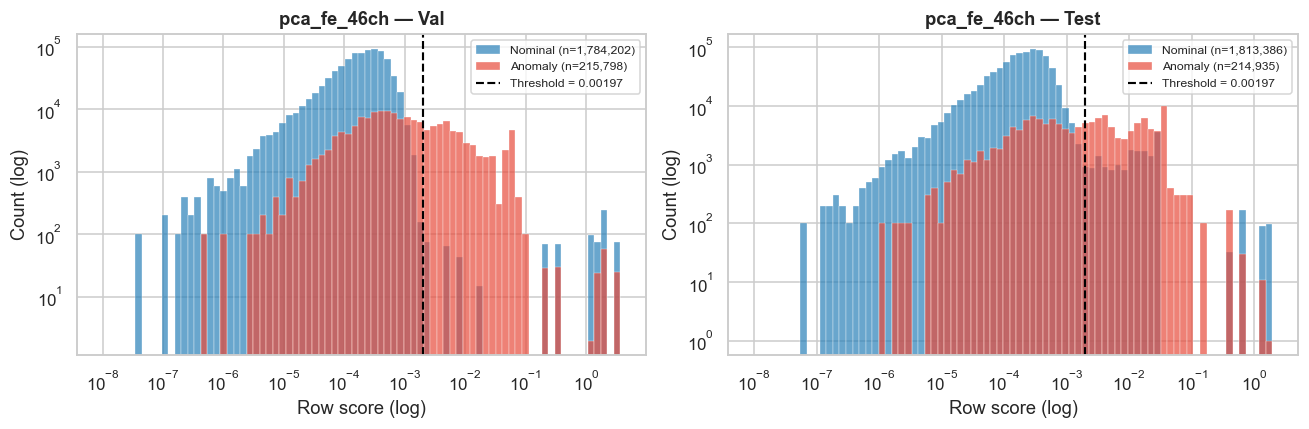

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
for ax, (label, scores, y_true) in zip(axes, [
    ('Val',  scores_val,  y_val),
    ('Test', scores_test, y_test),
]):
    nom = scores[y_true == 0]
    ano = scores[y_true == 1]
    lo = max(min(nom.min(), ano.min() if len(ano) else nom.min()), 1e-8)
    hi = max(nom.max(), ano.max() if len(ano) else nom.max())
    bins = np.logspace(np.log10(lo), np.log10(hi), 80)
    ax.hist(nom, bins=bins, color=NOMINAL_COLOR, alpha=0.7,
            label=f'Nominal (n={len(nom):,})', edgecolor='white', linewidth=0.3)
    if len(ano):
        ax.hist(ano, bins=bins, color=ANOMALY_COLOR, alpha=0.7,
                label=f'Anomaly (n={len(ano):,})', edgecolor='white', linewidth=0.3)
    ax.axvline(THRESHOLD, color='black', ls='--', lw=1.4,
               label=f'Threshold = {THRESHOLD:.5f}')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Row score (log)'); ax.set_ylabel('Count (log)')
    ax.set_title(f'{MODEL_NAME} — {label}', fontweight='bold')
    ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

---
## 5 — Metrics (baseline vs post-filter)

Two label sets per split:
* **baseline** — `scores > THRESHOLD`
* **post-filter** — `clean_predictions(min_len=100, max_gap=500)`

The post-filter is the FE-blessed output (cleaner block plot, same recall on
the kaggle internal test slice).

In [9]:
def _eval(scores, y_true):
    base = (scores > THRESHOLD).astype(np.int8)
    post = clean_predictions(base, min_len=POST_CFG['min_len'], max_gap=POST_CFG['max_gap'])
    m_b = compute_all_metrics(y_true, base)
    m_p = compute_all_metrics(y_true, post)
    return base, post, m_b, m_p

y_pred_val_b,  y_pred_val_p,  m_val_b,  m_val_p  = _eval(scores_val,  y_val)
y_pred_test_b, y_pred_test_p, m_test_b, m_test_p = _eval(scores_test, y_test)

tune_name = TUNE_METRIC.__name__
print(f'{MODEL_NAME} @ threshold {THRESHOLD:.5f}   (TUNE_METRIC = {tune_name})')
print(f'  >>> val  ESA F0.5  baseline = {m_val_b["esa_f05"]:.4f}   '
      f'post = {m_val_p["esa_f05"]:.4f}')
print(f'  >>> test ESA F0.5  baseline = {m_test_b["esa_f05"]:.4f}   '
      f'post = {m_test_p["esa_f05"]:.4f}')

pca_fe_46ch @ threshold 0.00197   (TUNE_METRIC = corrected_event_f05)
  >>> val  ESA F0.5  baseline = 0.8534   post = 0.8534
  >>> test ESA F0.5  baseline = 0.7167   post = 0.8180


In [10]:
GROUPS = {
    'Event-wise (headline)': [
        ('event_f05',            'Event F0.5',           '{:.4f}'),
        ('event_f1',             'Event F1',             '{:.4f}'),
        ('event_f2',             'Event F2',             '{:.4f}'),
        ('event_precision',      'Event precision',      '{:.4f}'),
        ('event_recall',         'Event recall',         '{:.4f}'),
        ('event_detection_rate', 'Event detection rate', '{:.4f}'),
        ('tp_events',            'Events hit',           'int_of_n'),
        ('fp_pred_events',       'FP predicted events',  '{:d}'),
    ],
    'ESA-corrected (Kaggle-style)': [
        ('esa_f05',       'ESA F0.5',      '{:.4f}'),
        ('esa_precision', 'ESA precision', '{:.4f}'),
        ('esa_recall',    'ESA recall',    '{:.4f}'),
        ('esa_tnr',       'ESA TNR',       '{:.4f}'),
    ],
    'Row-level (no tolerance)': [
        ('row_f1',        'Row F1',        '{:.4f}'),
        ('row_precision', 'Row precision', '{:.4f}'),
        ('row_recall',    'Row recall',    '{:.4f}'),
        ('__pos_rate',    'Positive rate', '{:.2%}'),
    ],
}

def _fmt_val(key, fmt, m, pos_rate):
    if key == '__pos_rate':
        v = pos_rate
    elif fmt == 'int_of_n':
        return f"{int(m['tp_events'])}/{int(m['n_events'])}"
    elif key == 'fp_pred_events':
        v = int(m[key])
    else:
        v = m[key]
    return fmt.format(v)

TUNE_LABEL = 'ESA F0.5'   # corrected_event_f05 → ESA F0.5

def _render_group(name, rows):
    df = pd.DataFrame(
        [
            {'Metric': lbl,
             'Val (base)' : _fmt_val(key, fmt, m_val_b,  float((y_pred_val_b  == 1).mean())),
             'Val (post)' : _fmt_val(key, fmt, m_val_p,  float((y_pred_val_p  == 1).mean())),
             'Test (base)': _fmt_val(key, fmt, m_test_b, float((y_pred_test_b == 1).mean())),
             'Test (post)': _fmt_val(key, fmt, m_test_p, float((y_pred_test_p == 1).mean()))}
            for key, lbl, fmt in rows
        ]
    ).set_index('Metric')
    print(f'\n── {name} ' + '─' * max(0, 55 - len(name)))
    if TUNE_LABEL in df.index:
        styled = df.style.apply(
            lambda r: ['background-color: #fff3bf' if r.name == TUNE_LABEL else '' for _ in r],
            axis=1,
        )
        from IPython.display import display
        display(styled)
    else:
        from IPython.display import display
        display(df)

for name, rows in GROUPS.items():
    _render_group(name, rows)


── Event-wise (headline) ──────────────────────────────────


,Val (base),Val (post),Test (base),Test (post)
Metric,,,,
Event F0.5,0.8537,0.8537,0.7216,0.8235
Event F1,0.7000,0.7000,0.6512,0.7000
Event F2,0.5932,0.5932,0.5932,0.6087
Event precision,1.0000,1.0000,0.7778,0.9333
Event recall,0.5385,0.5385,0.5600,0.5600
Event detection rate,0.5385,0.5385,0.5600,0.5600
Events hit,14/26,14/26,14/25,14/25
FP predicted events,0,0,4,1



── ESA-corrected (Kaggle-style) ───────────────────────────


,Val (base),Val (post),Test (base),Test (post)
Metric,,,,
ESA F0.5,0.8534,0.8534,0.7167,0.8180
ESA precision,0.9995,0.9995,0.7706,0.9245
ESA recall,0.5385,0.5385,0.5600,0.5600
ESA TNR,0.9995,0.9995,0.9908,0.9906



── Row-level (no tolerance) ───────────────────────────────


,Val (base),Val (post),Test (base),Test (post)
Metric,,,,
Row F1,0.3815,0.4054,0.4446,0.4574
Row precision,0.9840,0.9852,0.7980,0.8009
Row recall,0.2367,0.2552,0.3081,0.3201
Positive rate,2.60%,2.79%,4.09%,4.24%


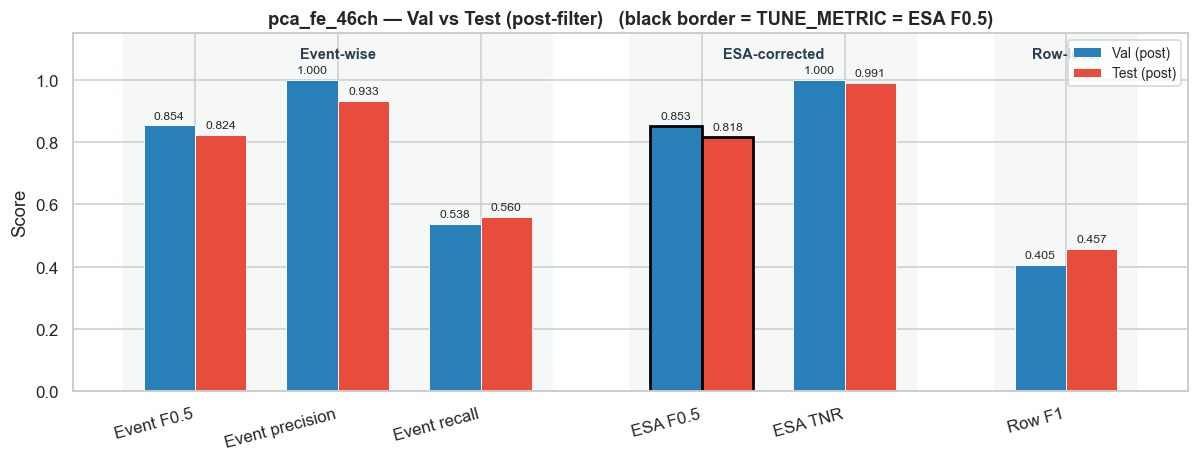

In [11]:
BAR_GROUPS = [
    ('Event-wise',    ['Event F0.5', 'Event precision', 'Event recall']),
    ('ESA-corrected', ['ESA F0.5', 'ESA TNR']),
    ('Row-level',     ['Row F1']),
]
LABEL_TO_KEY = {
    'Event F0.5'     : 'event_f05',
    'Event precision': 'event_precision',
    'Event recall'   : 'event_recall',
    'ESA F0.5'       : 'esa_f05',
    'ESA TNR'        : 'esa_tnr',
    'Row F1'         : 'row_f1',
}

fig, ax = plt.subplots(figsize=(11, 4.3))
w, gap = 0.36, 0.55
xs, xticks, xlabels, band_edges = [], [], [], []
cursor = 0.0
for gname, labels in BAR_GROUPS:
    grp_start = cursor
    for lbl in labels:
        xs.append(cursor); xticks.append(cursor); xlabels.append(lbl)
        cursor += 1.0
    band_edges.append((gname, grp_start - 0.5, cursor - 0.5))
    cursor += gap

xs        = np.asarray(xs)
vals_val  = [m_val_p [LABEL_TO_KEY[l]] for l in xlabels]
vals_test = [m_test_p[LABEL_TO_KEY[l]] for l in xlabels]
edges = ['black' if l == TUNE_LABEL else 'white' for l in xlabels]
lws   = [1.8     if l == TUNE_LABEL else 0.6     for l in xlabels]

b1 = ax.bar(xs - w/2, vals_val,  w, label='Val (post)',  color=NOMINAL_COLOR, edgecolor=edges, linewidth=lws)
b2 = ax.bar(xs + w/2, vals_test, w, label='Test (post)', color=ANOMALY_COLOR, edgecolor=edges, linewidth=lws)
ax.bar_label(b1, fmt='%.3f', fontsize=8, padding=3)
ax.bar_label(b2, fmt='%.3f', fontsize=8, padding=3)

for gname, xlo, xhi in band_edges:
    ax.axvspan(xlo, xhi, color='#ecf0f1', alpha=0.45, zorder=0)
    ax.text((xlo + xhi) / 2, 1.06, gname, ha='center', va='bottom',
            fontsize=9.5, fontweight='bold', color='#2c3e50')

ax.set_xticks(xticks); ax.set_xticklabels(xlabels, rotation=15, ha='right')
ax.set_ylim(0, 1.15); ax.set_ylabel('Score')
ax.set_title(f'{MODEL_NAME} — Val vs Test (post-filter)   '
             f'(black border = TUNE_METRIC = {TUNE_LABEL})', fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
fig.tight_layout(); plt.show()

---
## 6 — Timelines

Per-row score (detrended) with the threshold and true-anomaly bands. Predicted-
event ribbon underneath splits TPs (green) vs FPs (lavender). `log_y=True`
spreads small events that would otherwise be flattened by the largest spike.

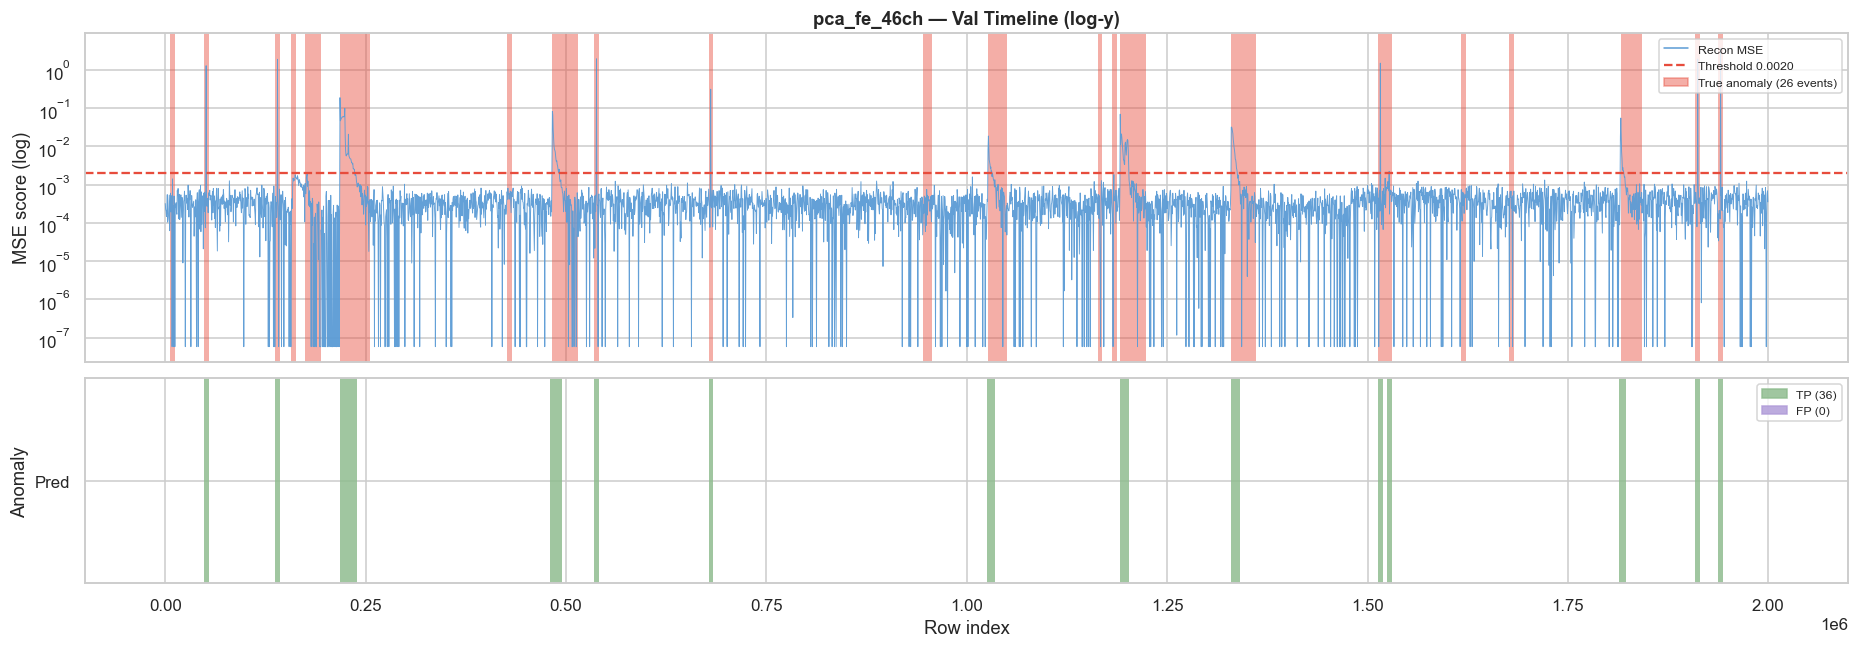

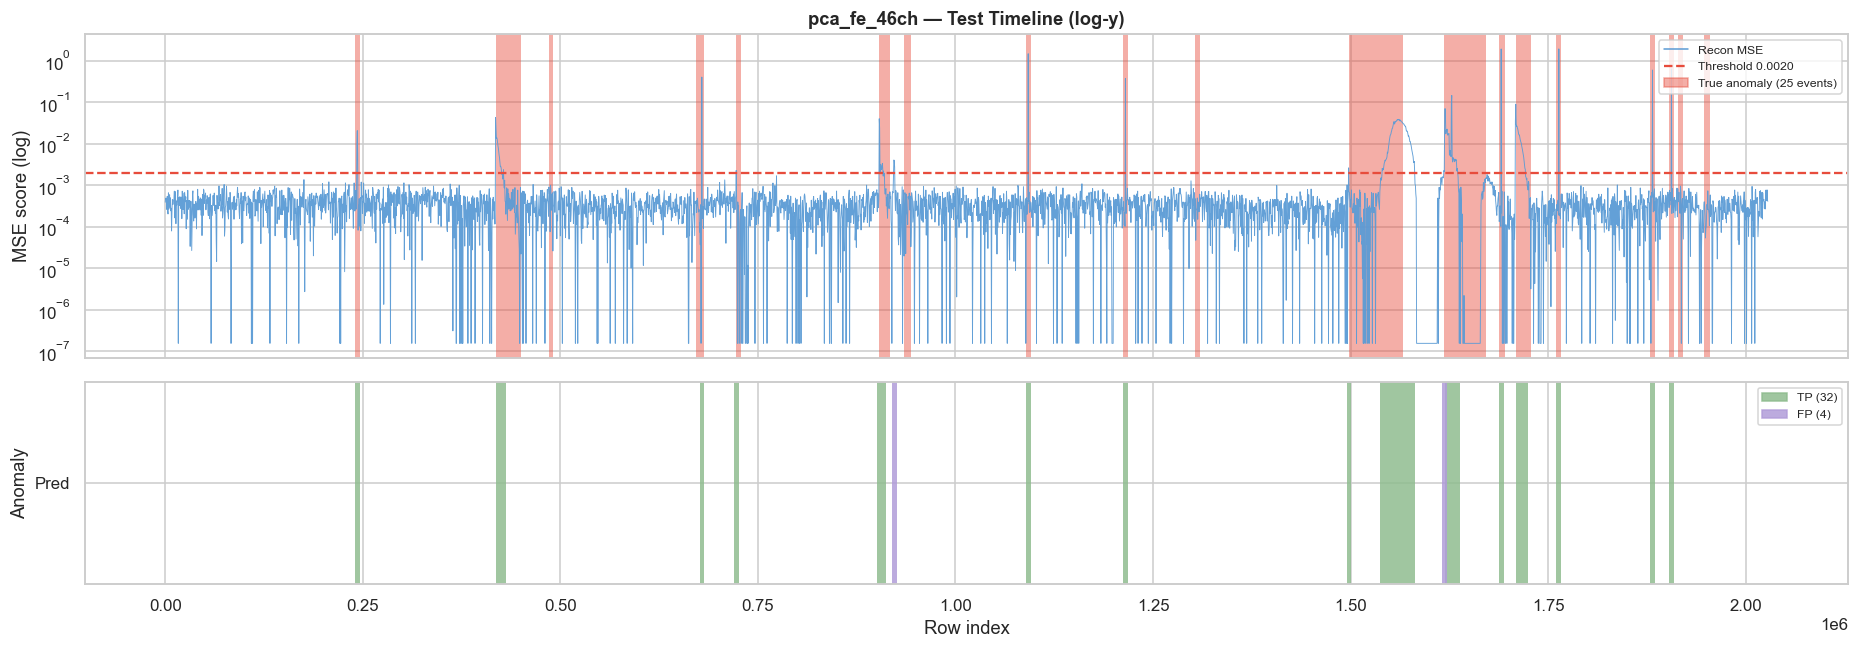

In [12]:
_ = plot_timeline(scores_val,  y_val,  THRESHOLD,
                  f'{MODEL_NAME} — Val Timeline (log-y)',  log_y=True)
plt.show(); plt.close()

_ = plot_timeline(scores_test, y_test, THRESHOLD,
                  f'{MODEL_NAME} — Test Timeline (log-y)', log_y=True)
plt.show(); plt.close()

---
## 7 - Per-event detection (baseline labels)

In [13]:
def event_table(scores, y_true, threshold, label):
    segments = find_anomaly_segments(y_true)
    y_pred   = (scores > threshold).astype(np.int8)
    rows = []
    for seg in segments:
        n_det = int(y_pred[seg['start']:seg['end']+1].sum())
        rows.append({
            'start'    : seg['start'],
            'end'      : seg['end'],
            'length'   : seg['length'],
            'detected' : n_det > 0,
            'hit_rate' : round(n_det / seg['length'], 3),
        })
    df = pd.DataFrame(rows)
    n_det  = int(df['detected'].sum())
    n_miss = len(df) - n_det
    print(f'{label}: {n_det}/{len(df)} events detected  ({n_miss} missed)')
    return df

df_val_ev  = event_table(scores_val,  y_val,  THRESHOLD, f'{MODEL_NAME} Val')
df_test_ev = event_table(scores_test, y_test, THRESHOLD, f'{MODEL_NAME} Test')

pca_fe_46ch Val: 14/26 events detected  (12 missed)
pca_fe_46ch Test: 14/25 events detected  (11 missed)


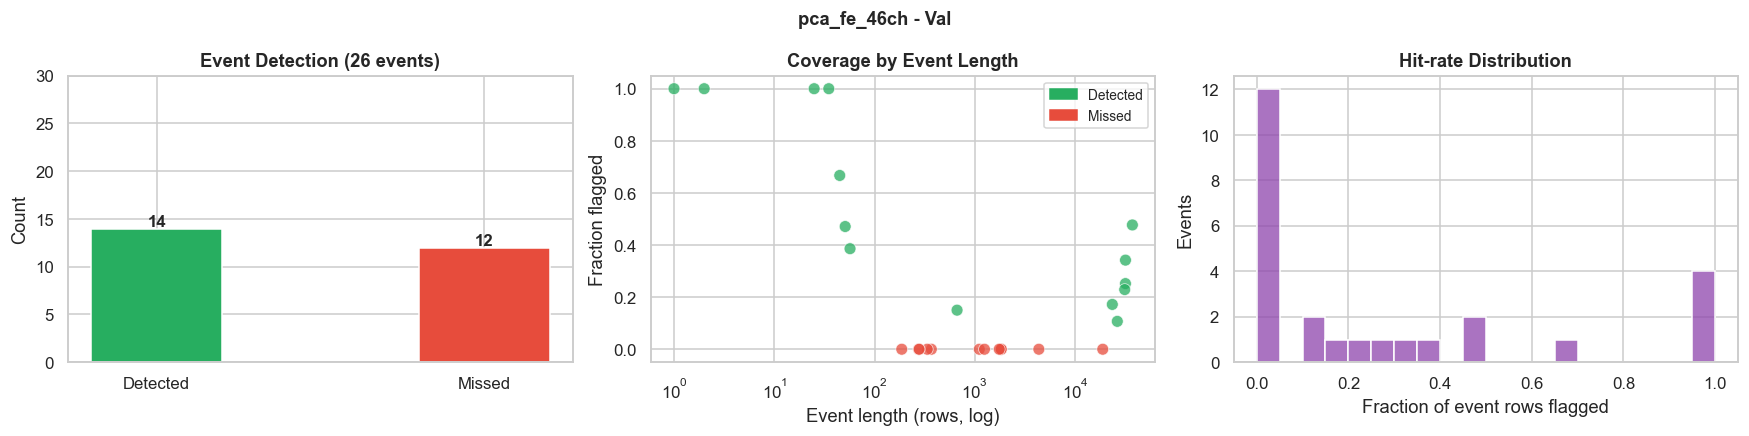

Missed events:
  start     end  length
   9219    9587     369
 158321  162679    4359
 174923  193837   18915
 429365  429700     336
 947186  949024    1839
 952299  954134    1836
1165985 1166260     276
1183740 1185494    1755
1522146 1522332     187
1522643 1523752    1110
1619693 1619971     279
1679098 1680347    1250


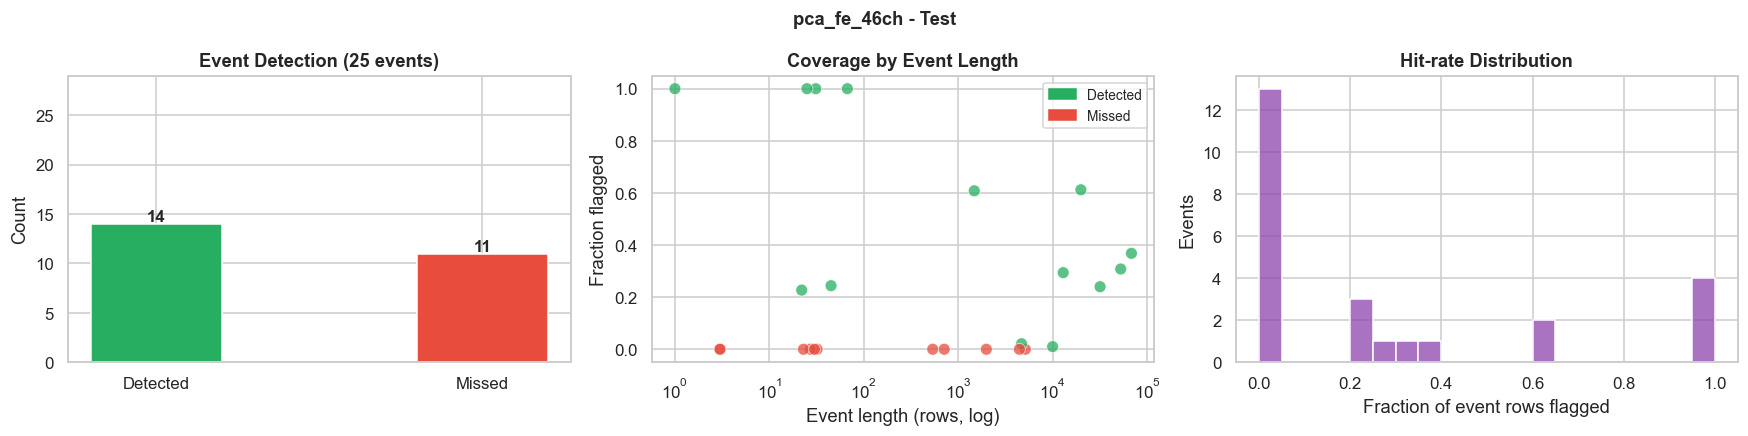

Missed events:
  start     end  length
 485619  490754    5136
 937585  937616      32
 938221  938247      27
 939737  939759      23
 940375  940404      30
1305587 1306297     711
1690836 1692821    1986
1916825 1917361     537
1949666 1949668       3
1949681 1949683       3
1949804 1954252    4449


In [14]:
def plot_event_analysis_local(df, title):
    n_det  = int(df['detected'].sum())
    n_miss = len(df) - n_det
    n_ev   = len(df)

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    counts = pd.Series({'Detected': n_det, 'Missed': n_miss})
    bars = axes[0].bar(counts.index, counts.values,
                       color=['#27ae60', ANOMALY_COLOR], edgecolor='white', width=0.4)
    for bar, v in zip(bars, counts.values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
                     str(v), ha='center', fontsize=11, fontweight='bold')
    axes[0].set_title(f'Event Detection ({n_ev} events)', fontweight='bold')
    axes[0].set_ylabel('Count'); axes[0].set_ylim(0, n_ev + 4)

    colors_pt = [('#27ae60' if d else ANOMALY_COLOR) for d in df['detected']]
    axes[1].scatter(df['length'], df['hit_rate'], c=colors_pt, s=60, alpha=0.75,
                    edgecolors='white', lw=0.5)
    axes[1].set_xscale('log')
    axes[1].set_xlabel('Event length (rows, log)'); axes[1].set_ylabel('Fraction flagged')
    axes[1].set_title('Coverage by Event Length', fontweight='bold'); axes[1].set_ylim(-0.05, 1.05)
    axes[1].legend(handles=[
        mpatches.Patch(color='#27ae60', label='Detected'),
        mpatches.Patch(color=ANOMALY_COLOR, label='Missed'),
    ], fontsize=9)

    sns.histplot(df['hit_rate'], bins=20, ax=axes[2], color='#8e44ad', edgecolor='white')
    axes[2].set_xlabel('Fraction of event rows flagged'); axes[2].set_ylabel('Events')
    axes[2].set_title('Hit-rate Distribution', fontweight='bold')

    fig.suptitle(title, fontsize=12, fontweight='bold')
    fig.tight_layout(); plt.show()

    if n_miss:
        print('Missed events:')
        print(df[~df['detected']][['start','end','length']].to_string(index=False))

plot_event_analysis_local(df_val_ev,  f'{MODEL_NAME} - Val')
plot_event_analysis_local(df_test_ev, f'{MODEL_NAME} - Test')

---
## 8 — Confusion matrix + top channels (within true-anomaly windows)

Row-level confusion + the top-k of the 46 FE channels ranked by mean
reconstruction MSE *inside true-anomaly windows*. Tells you which channels
actually drove the decision.

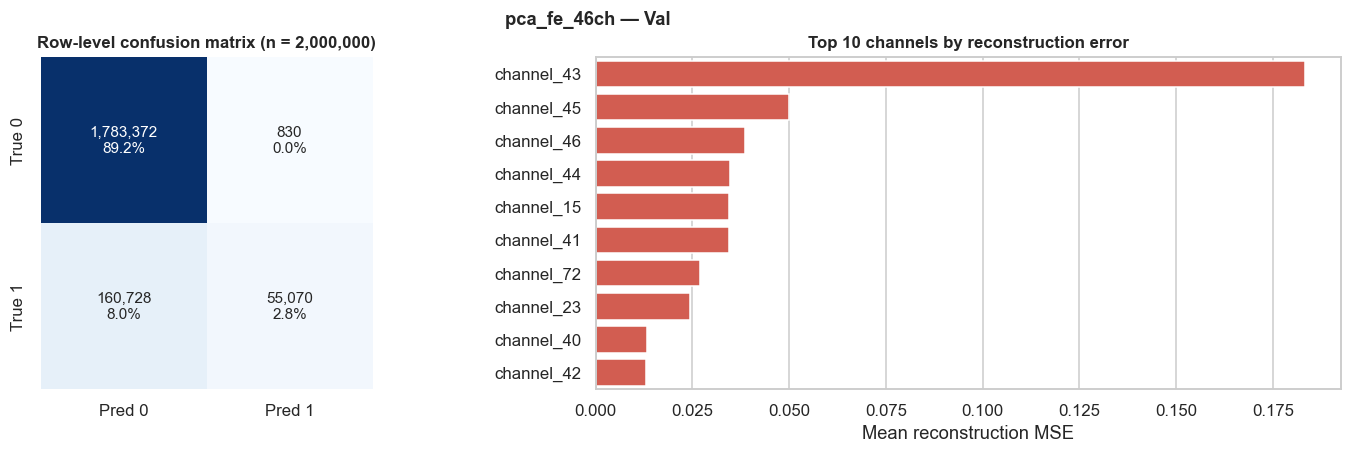

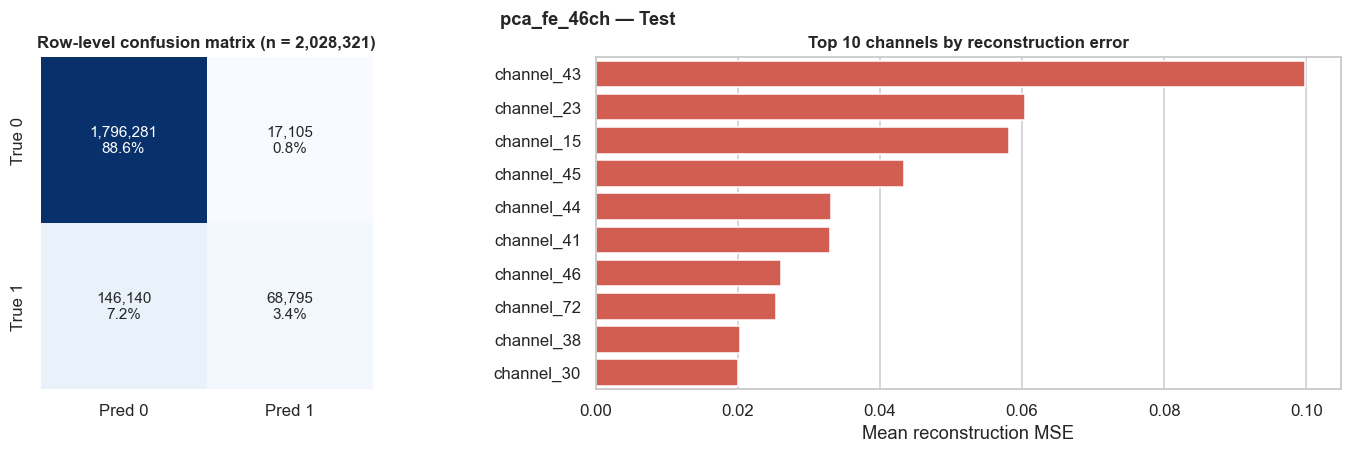

In [15]:
def per_channel_mse_in_anomaly_windows(rep, y_true, win):
    wcm   = rep['window_channel_mse']
    n_win = wcm.shape[0]
    if n_win == 0:
        return rep['per_channel_mse']
    y_by_win = y_true[: n_win * win].reshape(n_win, win).any(axis=1)
    if not y_by_win.any():
        return rep['per_channel_mse']
    return wcm[y_by_win].mean(axis=0)

for label, rep, y_t, y_pred in [
    ('Val',  rep_val,  y_val,  y_pred_val_p),
    ('Test', rep_test, y_test, y_pred_test_p),
]:
    per_ch_anom = per_channel_mse_in_anomaly_windows(rep, y_t, WIN)
    fig = plot_confusion_and_channel_errors(
        y_true          = y_t,
        y_pred          = y_pred,
        per_channel_mse = per_ch_anom,
        channel_names   = FEATURES_FE,
        top_k           = 10,
    )
    fig.suptitle(f'{MODEL_NAME} — {label}', fontsize=12, fontweight='bold', y=1.02)
    plt.show(); plt.close(fig)

---
## 9 - Bootstrap confidence interval (event-block resampling)

**Slow** — 200 iterations on 2M rows takes a few minutes per split.

Bootstrap CI (200 iterations, event-block) ...
  Val    F0.5 = 0.5872 ± 0.1030  95% CI [0.3929, 0.8000]
  Test   F0.5 = 0.6078 ± 0.1038  95% CI [0.4053, 0.7971]


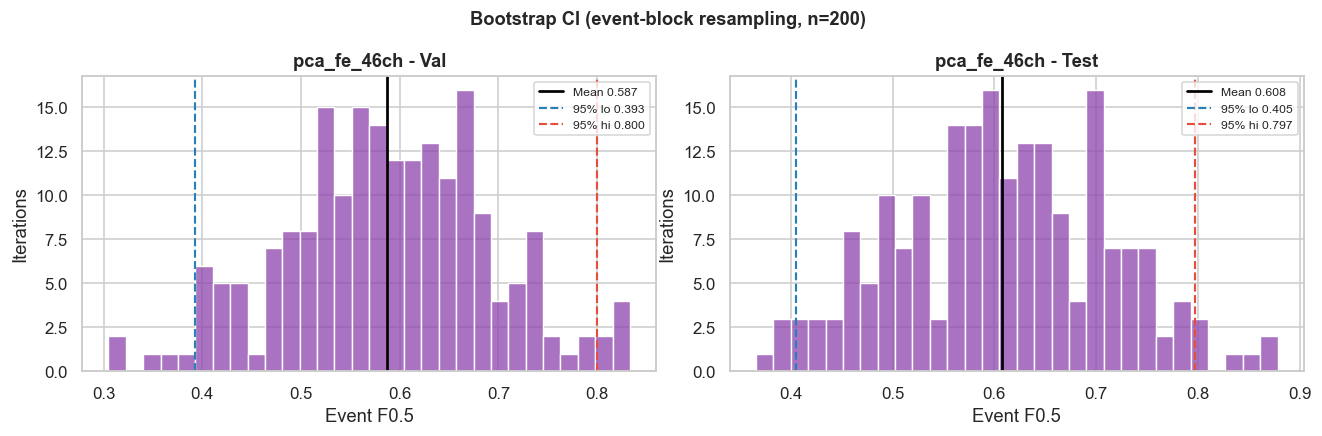

In [18]:
RUN_BOOTSTRAP = True    # flip to True to run

if RUN_BOOTSTRAP:
    print('Bootstrap CI (200 iterations, event-block) ...')
    ci_val  = bootstrap_f05_ci(y_val,  y_pred_val_p,  n_boot=200)
    ci_test = bootstrap_f05_ci(y_test, y_pred_test_p, n_boot=200)
    for label, ci in [('Val', ci_val), ('Test', ci_test)]:
        print(f'  {label:<6} F0.5 = {ci["mean"]:.4f} ± {ci["std"]:.4f}'
              f'  95% CI [{ci["ci_lo_95"]:.4f}, {ci["ci_hi_95"]:.4f}]')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, (label, ci) in zip(axes, [('Val', ci_val), ('Test', ci_test)]):
        sns.histplot(ci['all_scores'], bins=30, ax=ax, color='#8e44ad', edgecolor='white')
        ax.axvline(ci['mean'],     color='black',        lw=1.8, ls='-',  label=f'Mean {ci["mean"]:.3f}')
        ax.axvline(ci['ci_lo_95'], color=NOMINAL_COLOR,  lw=1.4, ls='--', label=f'95% lo {ci["ci_lo_95"]:.3f}')
        ax.axvline(ci['ci_hi_95'], color=ANOMALY_COLOR,  lw=1.4, ls='--', label=f'95% hi {ci["ci_hi_95"]:.3f}')
        ax.set_xlabel('Event F0.5'); ax.set_ylabel('Iterations')
        ax.set_title(f'{MODEL_NAME} - {label}', fontweight='bold')
        ax.legend(fontsize=8)
    fig.suptitle('Bootstrap CI (event-block resampling, n=200)', fontsize=12, fontweight='bold')
    fig.tight_layout(); plt.show()
else:
    print('RUN_BOOTSTRAP=False — skipping. Set to True to compute CI (~5 min).')